# GAAE Training — DELCODE DMN-Only (46 Nodes)

This notebook trains the GAAE model on DMN-only correlation matrices (46 nodes)
from `DATA/DELCODE/__v5__/dmn_only_schaefer`.

Key differences from the whole-brain notebook:
- Uses `GraphDMNDatasetInMemoryFiltered` (DMN file suffixes)
- Subject-level 60/20/20 train/val/test split via pre-generated CSVs
- Adjusted hyperparameters (`adjacency_k=8`, `latent_dim=32`)

## Imports

In [1]:
import os
import sys
import json
from datetime import datetime
from pathlib import Path

import random
import numpy as np
import torch
from torch_geometric.loader import DataLoader

# Project root
base_dir = Path('/mnt/e/fyassine/ad-early-detection/MODEL')
sys.path.insert(0, str(base_dir))

from model.GAAE.models import GraphAttentionAutoencoderConditioned
from model.GAAE.dataset import GraphDMNDatasetInMemoryFiltered
from model.GAAE.utils import knn_binary_adjacency_matrix_no_diag
from model.GAAE.train import train_model_with_val_notebook_train_loss

## Configuration

In [2]:
# Weights & Biases (optional — set to None to disable)
WANDB_PROJECT = "ad-early-detection-dmn"

try:
    import wandb
    wandb.login()
except Exception:
    wandb = None
    print("wandb not available — logging disabled")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/wunderlich/.netrc.
wandb: Currently logged in as: lakhalfrajyassine (lakhalfrajyassine-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Load hyperparameters
hyperparams_path = base_dir / "configs" / "gaae_delcode_dmn.json"
with open(hyperparams_path, "r") as handle:
    hyperparams = json.load(handle)

seed = hyperparams["seed"]
batch_size = hyperparams["batch_size"]
learning_rate = hyperparams["learning_rate"]
adj_loss_weight = hyperparams["adj_loss_weight"]
n_epochs = hyperparams["epochs"]
early_stopping_patience = hyperparams["early_stopping_patience"]

out_features = hyperparams["latent_dim"]
num_heads = hyperparams["num_heads"]
cond_dim = hyperparams["cond_dim"]
dropout = hyperparams["dropout"]
model_save_path = hyperparams.get("model_save_path")

adjacency_args = {"k": hyperparams["adjacency_k"]}
num_workers = hyperparams["num_workers"]
file_variant = hyperparams.get("file_variant", "z_transformed")

print(f"Hyperparameters: {json.dumps(hyperparams, indent=2)}")

Hyperparameters: {
  "seed": 100,
  "batch_size": 64,
  "learning_rate": 0.001,
  "adj_loss_weight": 0.1,
  "epochs": 1000,
  "early_stopping_patience": 100,
  "latent_dim": 32,
  "num_heads": 2,
  "cond_dim": 2,
  "dropout": 0.5,
  "adjacency_k": 8,
  "num_workers": 8,
  "file_variant": "z_transformed",
  "dense_use_abs": false,
  "model_save_path": null
}


In [5]:
# Set random seeds for reproducibility
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(seed)

def worker_init_fn(worker_id):
    worker_seed = seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

print(f"Random seed set to: {seed}")

Random seed set to: 100


## Dataset

Uses pre-generated `train.csv`, `val.csv`, `test.csv` for subject-level splits.
Each CSV has a `Repseudonym` column listing the subject IDs in that split.

In [6]:
# DMN data root
dmn_data_root = "/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v5__/dmn_only_schaefer"

# Split CSV paths (in metadata directory, alongside cohorts.csv)
metadata_dir = "/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v5__/metadata"
train_csv = os.path.join(metadata_dir, "train.csv")
val_csv   = os.path.join(metadata_dir, "val.csv")
test_csv  = os.path.join(metadata_dir, "test.csv")

# Create datasets for each split
train_dataset = GraphDMNDatasetInMemoryFiltered(
    root=dmn_data_root,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    filter_csv_path=train_csv,
    separator=",",
    file_variant=file_variant,
)

val_dataset = GraphDMNDatasetInMemoryFiltered(
    root=dmn_data_root,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    filter_csv_path=val_csv,
    separator=",",
    file_variant=file_variant,
)

test_dataset = GraphDMNDatasetInMemoryFiltered(
    root=dmn_data_root,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    filter_csv_path=test_csv,
    separator=",",
    file_variant=file_variant,
)

print(f"Train: {len(train_dataset)} samples")
print(f"Val:   {len(val_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")
print(f"Feature shape: {train_dataset[0].x.shape}")

Train: 457 samples
Val:   89 samples
Test:  63 samples
Feature shape: torch.Size([46, 46])


In [7]:
# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    worker_init_fn=worker_init_fn,
    persistent_workers=True if num_workers > 0 else False,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    worker_init_fn=worker_init_fn,
    persistent_workers=True if num_workers > 0 else False,
    pin_memory=True if torch.cuda.is_available() else False
)

dataset_info = {
    "dataset_name": "DMN-only Schaefer 46-node (60/20/20 subject-level split)",
    "kNN_param": adjacency_args['k'],
    "correlation_type": file_variant,
    "num_features": train_dataset[0].x.size(1),
    "train_dataset_size": len(train_dataset),
    "val_dataset_size": len(val_dataset),
    "test_dataset_size": len(test_dataset),
    "batch_size": batch_size
}
print(f"Dataset info: {json.dumps(dataset_info, indent=2)}")

Dataset info: {
  "dataset_name": "DMN-only Schaefer 46-node (60/20/20 subject-level split)",
  "kNN_param": 8,
  "correlation_type": "z_transformed",
  "num_features": 46,
  "train_dataset_size": 457,
  "val_dataset_size": 89,
  "test_dataset_size": 63,
  "batch_size": 64
}


## Model

In [8]:
# Derive in_features from the dataset
in_features = train_dataset[0].x.size(1)
hidden_dim = in_features  # same as in_features by default

model = GraphAttentionAutoencoderConditioned(
    in_features=in_features,
    hidden_dim=hidden_dim,
    out_features=out_features,
    cond_dim=cond_dim,
    num_heads=num_heads,
    dropout=dropout
).to(device)

model_config = {
    "model_type": model.__class__.__name__,
    "in_features": in_features,
    "hidden_size": hidden_dim,
    "latent_dim": out_features,
    "attention_heads": num_heads,
    "device": device.type,
    "dropout": dropout
}

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(f"Model: {model.__class__.__name__}")
print(f"  in_features={in_features}, hidden_dim={hidden_dim}, out_features={out_features}")
print(f"  num_heads={num_heads}, dropout={dropout}")

Model: GraphAttentionAutoencoderConditioned
  in_features=46, hidden_dim=46, out_features=32
  num_heads=2, dropout=0.5


## Training

In [9]:
best_model, history = train_model_with_val_notebook_train_loss(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    batch_size=batch_size,
    learning_rate=learning_rate,
    model_config=model_config,
    adj_loss_weight=adj_loss_weight,
    epochs=n_epochs,
    early_stopping_patience=early_stopping_patience,
    dataset_info=dataset_info,
    project_name=WANDB_PROJECT
)

# Save model
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
try:
    wandb_run_name = wandb.run.name if wandb and wandb.run and wandb.run.name else f"run_{run_timestamp}"
except:
    wandb_run_name = f"run_{run_timestamp}"

run_artifact_dir = os.path.join("checkpoints", wandb_run_name)
os.makedirs(run_artifact_dir, exist_ok=True)

model_file = os.path.join(run_artifact_dir, f"model_{wandb_run_name}.pth")
torch.save(best_model, model_file)
print(f"Saved best model to {model_file}")

config_to_save = {
    "run_name": wandb_run_name,
    "timestamp": run_timestamp,
    "dataset_info": dataset_info,
    "model_config": model_config,
    "training_config": {
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "adj_loss_weight": adj_loss_weight,
        "epochs": n_epochs,
        "early_stopping_patience": early_stopping_patience
    }
}

def json_serial(obj):
    if isinstance(obj, (datetime, torch.device)):
        return str(obj)
    raise TypeError(f"Type {type(obj)} not serializable")

config_file = os.path.join(run_artifact_dir, "run_config.json")
with open(config_file, "w") as f:
    json.dump(config_to_save, f, indent=4, default=json_serial)
print(f"Saved run configuration to {config_file}")

Training Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved best model to checkpoints/autumn-river-2/model_autumn-river-2.pth
Saved run configuration to checkpoints/autumn-river-2/run_config.json


## Loss Curves

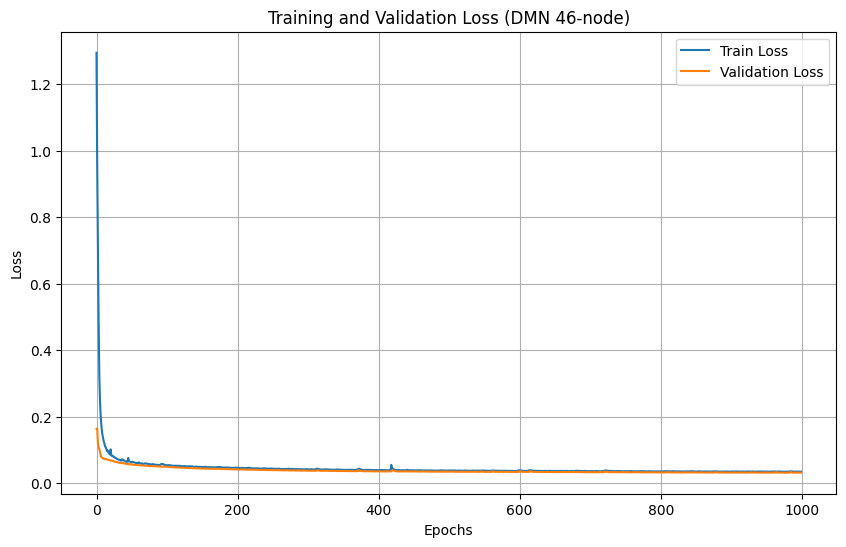

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (DMN 46-node)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Box Plots

/tmp/ipykernel_193008/4218867830.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_193008/4218867830.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


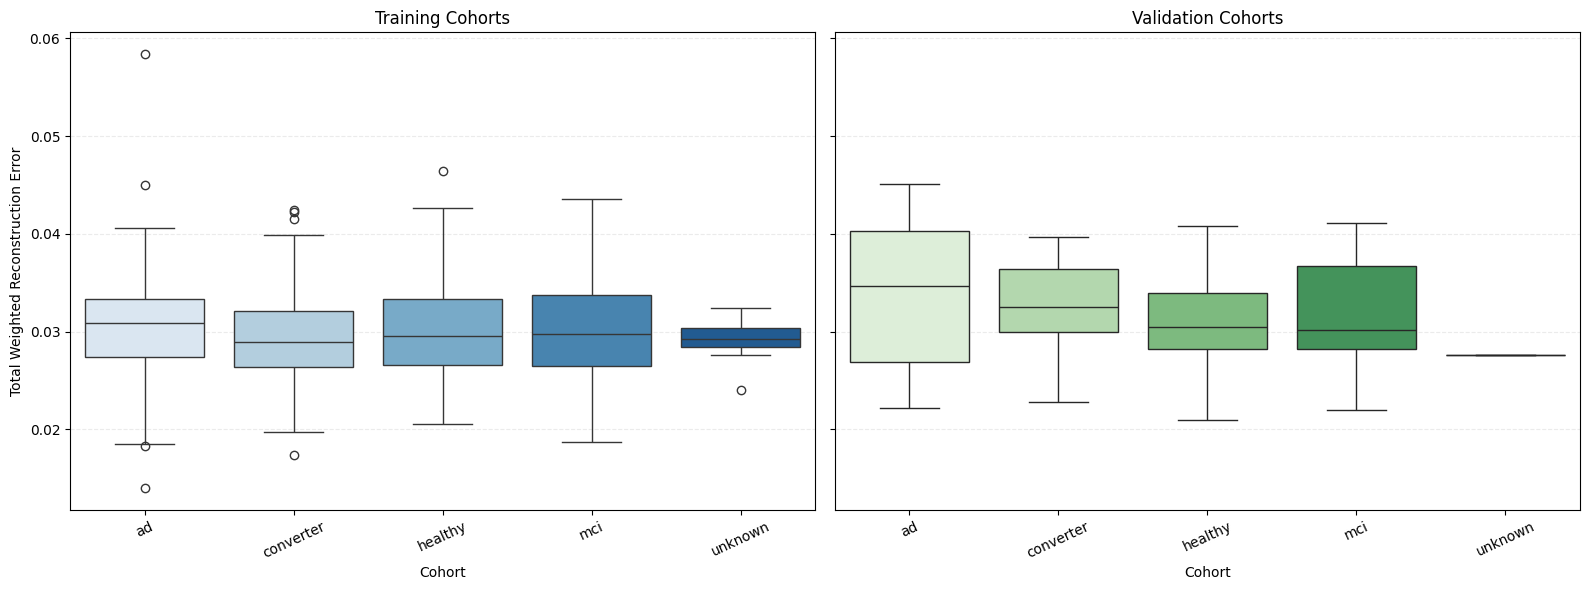

Train cohort counts:
Cohort
ad            77
converter    146
healthy      150
mci           74
unknown       10
dtype: int64

Validation cohort counts:
Cohort
ad           14
converter    29
healthy      30
mci          15
unknown       1
dtype: int64


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj

cohorts_csv = os.path.join(metadata_dir, "cohorts.csv")
cohort_df = pd.read_csv(cohorts_csv)

# Use the first available diagnosis per subject (typically baseline).
subject_cohort_map = (
    cohort_df[["Pseudonym", "diagnosis"]]
    .dropna(subset=["Pseudonym", "diagnosis"])
    .drop_duplicates(subset=["Pseudonym"], keep="first")
    .assign(diagnosis=lambda d: d["diagnosis"].astype(str).str.lower().str.strip())
    .set_index("Pseudonym")["diagnosis"]
    .to_dict()
)

def compute_split_errors_by_cohort(dataset, split_name):
    records = []
    model.eval()

    for data in dataset:
        data = data.to(device)
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        patient_id = getattr(data, "patient_id", None)
        cohort = subject_cohort_map.get(patient_id, "unknown")

        cond_vec = torch.tensor(
            [[data.patient_age.item(), float(data.patient_sex.item())]],
            device=device,
        )
        batch_mask = torch.zeros(x.size(0), dtype=torch.long, device=device)

        with torch.no_grad():
            _, x_reconstructed, adj_reconstructed_edge, _ = model(
                x, edge_index, edge_attr, cond_vec, batch_mask
            )

        x_error = F.mse_loss(x_reconstructed, x).item()
        adj_original = to_dense_adj(edge_index, max_num_nodes=x.size(0)).squeeze(0)
        adj_reconstructed_dense = to_dense_adj(
            edge_index,
            edge_attr=adj_reconstructed_edge,
            max_num_nodes=x.size(0),
        ).squeeze(0)
        adj_error = F.binary_cross_entropy(adj_reconstructed_dense, adj_original).item()
        total_error = x_error + adj_loss_weight * adj_error

        records.append(
            {
                "Split": split_name,
                "Cohort": cohort,
                "Total Error": total_error,
            }
        )

    return pd.DataFrame(records)

train_errors_df = compute_split_errors_by_cohort(train_dataset, "Train")
val_errors_df = compute_split_errors_by_cohort(val_dataset, "Validation")

# Keep consistent cohort ordering across both plots.
cohort_order = sorted(
    set(train_errors_df["Cohort"].dropna().unique())
    | set(val_errors_df["Cohort"].dropna().unique())
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.boxplot(
    data=train_errors_df,
    x="Cohort",
    y="Total Error",
    order=cohort_order,
    palette="Blues",
    ax=axes[0],
)
axes[0].set_title("Training Cohorts")
axes[0].set_xlabel("Cohort")
axes[0].set_ylabel("Total Weighted Reconstruction Error")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.25, linestyle="--")

sns.boxplot(
    data=val_errors_df,
    x="Cohort",
    y="Total Error",
    order=cohort_order,
    palette="Greens",
    ax=axes[1],
)
axes[1].set_title("Validation Cohorts")
axes[1].set_xlabel("Cohort")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.25, linestyle="--")

plt.tight_layout()
plt.show()

print("Train cohort counts:")
print(train_errors_df.groupby("Cohort").size().sort_index())

print("\nValidation cohort counts:")
print(val_errors_df.groupby("Cohort").size().sort_index())